<a href="https://colab.research.google.com/github/BrayFlo/Mineria-Datos/blob/main/ClusterAglomerativo_Ejer2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.cluster import AgglomerativeClustering


# =====================================================================
# EJERCICIO 2: Segmentación de clientes según Edad y Gasto Mensual
# =====================================================================


In [2]:
# 1. Definición de los Datos
# Estructura: [Edad, Gasto Mensual]
X = np.array([
    [20, 100],   # Cliente A: Joven, bajo gasto
    [22, 120],   # Cliente B: Joven, bajo gasto
    [23, 140],   # Cliente C: Joven, bajo gasto
    [45, 700],   # Cliente D: Mediana edad, gasto medio
    [46, 750],   # Cliente E: Mediana edad, gasto medio
    [48, 720],   # Cliente F: Mediana edad, gasto medio
    [60, 1500],  # Cliente G: Senior, alto gasto
    [62, 1600]   # Cliente H: Senior, alto gasto
])

etiquetas = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']

In [3]:
# Estilo visual moderno para las gráficas
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig = plt.figure(figsize=(16, 10))


<Figure size 1600x1000 with 0 Axes>

(0.0, 1800.0)

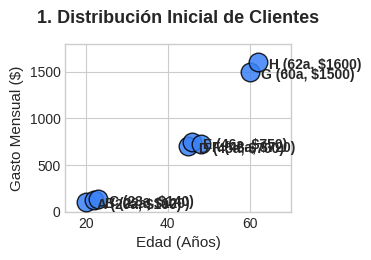

In [4]:
# ---------------------------------------------------------------------
# ACTIVIDAD 1: Graficar los datos iniciales
# ---------------------------------------------------------------------
ax1 = plt.subplot(2, 2, 1)
ax1.scatter(X[:, 0], X[:, 1], color='#3b82f6', s=180, edgecolors='black', zorder=3, alpha=0.85)
for i, txt in enumerate(etiquetas):
    ax1.annotate(f"{txt} ({X[i,0]}a, ${X[i,1]})", (X[i, 0], X[i, 1]),
                 xytext=(8, -5), textcoords='offset points', fontsize=10, fontweight='bold')
ax1.set_title("1. Distribución Inicial de Clientes", fontsize=13, fontweight='bold', pad=15)
ax1.set_xlabel("Edad (Años)", fontsize=11)
ax1.set_ylabel("Gasto Mensual ($)", fontsize=11)
ax1.set_xlim(15, 70)
ax1.set_ylim(0, 1800)

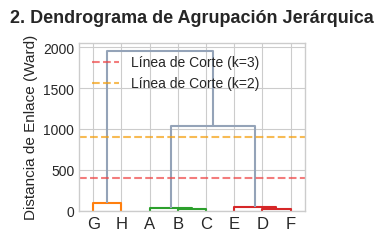

In [5]:
# ---------------------------------------------------------------------
# ACTIVIDAD 2: Generar el Dendrograma (Clustering Jerárquico Linkage Ward)
# ---------------------------------------------------------------------
ax2 = plt.subplot(2, 2, 2)
# Usamos 'ward' para minimizar la varianza dentro de los clusters resultantes
Z = linkage(X, method='ward')
dendrogram(Z, labels=etiquetas, ax=ax2, color_threshold=400,
           above_threshold_color='#94a3b8')
ax2.set_title("2. Dendrograma de Agrupación Jerárquica", fontsize=13, fontweight='bold', pad=15)
ax2.set_ylabel("Distancia de Enlace (Ward)", fontsize=11)
ax2.axhline(y=400, color='#ef4444', linestyle='--', alpha=0.7, label='Línea de Corte (k=3)')
ax2.axhline(y=900, color='#f59e0b', linestyle='--', alpha=0.7, label='Línea de Corte (k=2)')
ax2.legend(loc='upper left')

(0.0, 1800.0)

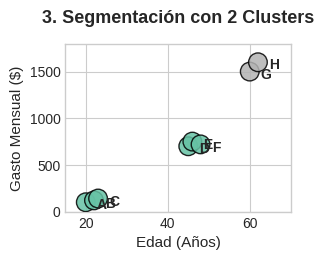

In [6]:
# ---------------------------------------------------------------------
# ACTIVIDAD 3: Agrupación con n_clusters = 2
# ---------------------------------------------------------------------
ax3 = plt.subplot(2, 2, 3)
# Ajustamos con AgglomerativeClustering de Scikit-Learn
hc_2 = AgglomerativeClustering(n_clusters=2, metric='euclidean', linkage='ward')
clusters_2 = hc_2.fit_predict(X)

# Graficar los 2 clusters
scatter_2 = ax3.scatter(X[:, 0], X[:, 1], c=clusters_2, cmap='Set2', s=180, edgecolors='black', zorder=3, alpha=0.85)
for i, txt in enumerate(etiquetas):
    ax3.annotate(txt, (X[i, 0], X[i, 1]), xytext=(8, -5), textcoords='offset points', fontsize=10, fontweight='bold')
ax3.set_title("3. Segmentación con 2 Clusters", fontsize=13, fontweight='bold', pad=15)
ax3.set_xlabel("Edad (Años)", fontsize=11)
ax3.set_ylabel("Gasto Mensual ($)", fontsize=11)
ax3.set_xlim(15, 70)
ax3.set_ylim(0, 1800)


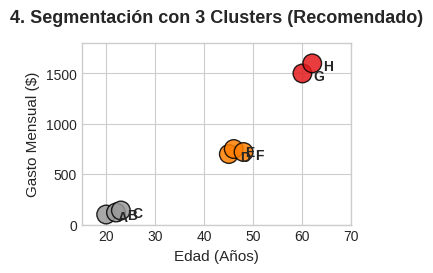

In [7]:
# ---------------------------------------------------------------------
# ACTIVIDAD 3 (Cont.): Agrupación con n_clusters = 3
# ---------------------------------------------------------------------
ax4 = plt.subplot(2, 2, 4)
hc_3 = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
clusters_3 = hc_3.fit_predict(X)

# Graficar los 3 clusters
scatter_3 = ax4.scatter(X[:, 0], X[:, 1], c=clusters_3, cmap='Set1', s=180, edgecolors='black', zorder=3, alpha=0.85)
for i, txt in enumerate(etiquetas):
    ax4.annotate(txt, (X[i, 0], X[i, 1]), xytext=(8, -5), textcoords='offset points', fontsize=10, fontweight='bold')
ax4.set_title("4. Segmentación con 3 Clusters (Recomendado)", fontsize=13, fontweight='bold', pad=15)
ax4.set_xlabel("Edad (Años)", fontsize=11)
ax4.set_ylabel("Gasto Mensual ($)", fontsize=11)
ax4.set_xlim(15, 70)
ax4.set_ylim(0, 1800)

plt.tight_layout()
plt.show()

In [8]:
# =====================================================================
# RESUMEN DE COMPROBACIÓN MATEMÁTICA / ESCALADO (Opcional pero recomendado)
# =====================================================================
print("--- ANÁLISIS DE LA MATRIZ DE DISTANCIAS ---")
print("Rango de la variable 'Edad':", X[:, 0].max() - X[:, 0].min())
print("Rango de la variable 'Gasto Mensual':", X[:, 1].max() - X[:, 1].min())
print("\nNota Técnica: La diferencia de escala (1500 vs 42) provoca que la distancia ")
print("Euclidiana sea dominada por el 'Gasto Mensual'. En conjuntos de datos reales,")
print("se aconseja usar StandardScaler antes del clustering si ambas variables tienen")
print("la misma importancia relativa para el negocio.")

--- ANÁLISIS DE LA MATRIZ DE DISTANCIAS ---
Rango de la variable 'Edad': 42
Rango de la variable 'Gasto Mensual': 1500

Nota Técnica: La diferencia de escala (1500 vs 42) provoca que la distancia 
Euclidiana sea dominada por el 'Gasto Mensual'. En conjuntos de datos reales,
se aconseja usar StandardScaler antes del clustering si ambas variables tienen
la misma importancia relativa para el negocio.


1. ¿Qué clientes parecen más similares?

Visualmente (y analizando sus coordenadas), los clientes se agrupan de forma natural en tres parejas extremadamente similares debido a la proximidad en sus variables:

Clientes A, B y C (Sector Joven): Sus edades están entre los $20$ y $23$ años, y su gasto mensual oscila apenas entre $\$100$ y $\$140$. La distancia entre ellos es muy pequeña.

Clientes D, E y F (Sector Mediana Edad): Edades muy compactas entre los $45$ y $48$ años, con gastos estables entre $\$700$ y $\$750$.

Clientes G y H (Sector Senior/VIP): Edades muy cercanas ($60$ y $62$ años) con gastos sumamente altos ($1500$ y $1600$ dólares respectivamente).

2. ¿Qué grupos naturales identifica el algoritmo?

Dependiendo de dónde "cortemos" el dendrograma, el algoritmo identifica los siguientes grupos:

Con $k = 3$ (Corte recomendado, altura aprox. $400$):
Identifica de forma perfecta los tres grupos naturales del negocio:

Grupo 1 (Bajo Gasto): Clientes A, B, C.

Grupo 2 (Gasto Medio): Clientes D, E, F.

Grupo 3 (Alto Gasto): Clientes G, H.

Con $k = 2$ (Corte más arriba, altura aprox. $900$):
El algoritmo se ve obligado a fusionar los dos grupos con menor distancia relativa entre ellos. Por lo tanto, agrupa a los jóvenes (Bajo Gasto) y a los adultos de mediana edad (Gasto Medio) en un solo gran "supergrupo", manteniendo a los Seniors (G, H) en un grupo premium totalmente aislado debido a su altísima distancia en el eje de consumo.

3. ¿Qué representa cada clúster desde el punto de vista comercial?

Si analizamos la segmentación óptima ($k = 3$), cada clúster describe un arquetipo o buyer persona muy claro para la tienda:
4. ¿Cuál sería una estrategia de marketing para cada grupo?

Para maximizar el retorno de inversión, no se les puede tratar de la misma manera:

Estrategia para C1 (Jóvenes Iniciadores):

Enfoque: Conversión y adquisición.

Acciones: Campañas $100\%$ en canales digitales (redes sociales), programas de recomendación "trae a un amigo", descuentos para estudiantes, gamificación en la app móvil y promoción de productos de bajo costo de entrada.

Estrategia para C2 (Familias Estables):

Enfoque: Retención y venta cruzada (cross-selling).

Acciones: Programas de suscripción mensual (envíos gratis), cupones familiares, venta cruzada de productos para el hogar, y campañas de email marketing con ofertas personalizadas basadas en sus compras anteriores.

Estrategia para C3 (Clientes VIP):

Enfoque: Experiencia exclusiva y servicio.

Acciones: Trato altamente personalizado (gestor de cuentas dedicado), invitaciones a preventas exclusivas, regalos por fidelidad, empaque prémium, entrega prioritaria y canales de atención telefónica de alta prioridad.

5. ¿Por qué el algoritmo agrupa ciertos clientes? (Análisis Matemático)

El algoritmo agrupa a los clientes basándose en la distancia euclidiana en un espacio bidimensional